In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [16]:
df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding='latin1')

In [17]:
df["Delivery_Delay"] = (
    df["Days for shipping (real)"]
    - df["Days for shipment (scheduled)"]
)


In [20]:
#Calculate KPIs
late_rate = df["Late_delivery_risk"].mean() * 100
avg_delay = df["Delivery_Delay"].mean()

print("Late Delivery Rate:", round(late_rate, 2), "%")
print("Average Delivery Delay:", round(avg_delay, 2), "days")

Late Delivery Rate: 58.3 %
Average Delivery Delay: 0.56 days


In [21]:
# Analyze shipping modes
mode_analysis = df.groupby("Shipping Mode")["Late_delivery_risk"].mean() * 100
print("\nLate Delivery Rate by Shipping Mode:")
print(mode_analysis)


Late Delivery Rate by Shipping Mode:
Shipping Mode
First Class       98.947857
Same Day          51.323988
Second Class      77.716163
Standard Class    38.021773
Name: Late_delivery_risk, dtype: float64


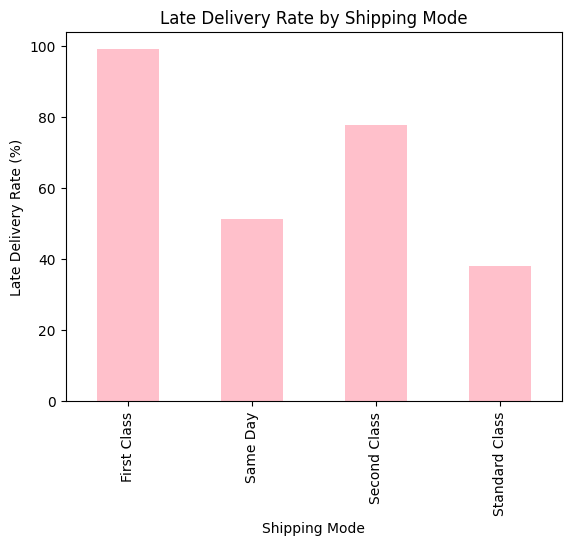

In [23]:
# Visualization
mode_analysis.plot(kind="bar",color="pink")
plt.title("Late Delivery Rate by Shipping Mode")
plt.ylabel("Late Delivery Rate (%)")
plt.xlabel("Shipping Mode")
plt.show()

In [25]:
# Machine Learning
features = [
    "Days for shipment (scheduled)",
    "Order Item Quantity"
]
X = df[features].fillna(0)
y = df["Late_delivery_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [26]:
#  Prediction and evaluation
prediction = model.predict(X_test)

accuracy = accuracy_score(y_test, prediction)

print("\nRandom Forest Accuracy:",
      round(accuracy * 100, 2), "%")


Random Forest Accuracy: 72.71 %
